# 06 — Baseline backtest results (Week 3 deliverable)

Four variants: **v0** (unconditional, DMV benchmark Table II) and **v1** (ex-ante median
threshold), **gross** and **net** of the calibrated cost grid (README §8bis).

Outputs → `results/tables/table_s3_metrics.csv`, `table_s3_dmv_sanity.csv`,
`results/figures/fig_backtest_s3.png`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
P = ROOT / "data" / "processed"
TAGS = {"v0 gross": "v0", "v0 net": "v0_net", "v1 gross": "v1", "v1 net": "v1_net"}

rows = []
for label, tag in TAGS.items():
    q = pd.read_parquet(P / f"backtest_{tag}_quarterly.parquet")
    d = pd.read_parquet(P / f"backtest_{tag}_daily.parquet")
    r, dr = q["ret_q"].astype(float), d["ret"].astype(float)
    cum = (1 + dr).cumprod()
    down = r[r < 0]
    cost = (q.loc[q["traded"], "cost_entry"] + q.loc[q["traded"], "cost_hedge"]).mean() \
        if "cost_entry" in q.columns and q["cost_entry"].abs().sum() > 0 else 0.0
    rows.append({
        "variant": label,
        "quarters traded": f"{int(q['traded'].sum())}/{len(q)}",
        "mean quarterly return": r.mean(),
        "t-stat": r.mean() / r.std() * np.sqrt(len(r)),   # non-overlapping quarters
        "Sharpe (ann.)": r.mean() / r.std() * 2,
        "Sortino (ann.)": r.mean() / down.std() * 2 if len(down) > 2 else np.nan,
        "skew": r.skew(),
        "% quarters > 0": (r > 0).mean(),
        "cumulative (×)": cum.iloc[-1],
        "maxDD (daily)": (cum / cum.cummax() - 1).min(),
        "cost/traded quarter": cost,
    })
met = pd.DataFrame(rows).set_index("variant")
(ROOT / "results" / "tables").mkdir(parents=True, exist_ok=True)
met.to_csv(ROOT / "results" / "tables" / "table_s3_metrics.csv")
met.round(3)

,quarters traded,mean quarterly return,t-stat,Sharpe (ann.),Sortino (ann.),skew,% quarters > 0,cumulative (×),maxDD (daily),cost/traded quarter
variant,,,,,,,,,,
v0 gross,115/115,0.073,4.114,0.767,0.898,-1.291,0.696,164.623,-0.958,0.000
v0 net,115/115,0.039,2.240,0.418,0.492,-1.332,0.661,2.538,-0.990,0.033
v1 gross,58/115,0.043,2.991,0.558,0.417,-1.452,0.852,12.988,-0.959,0.000
v1 net,58/115,0.025,1.793,0.334,0.250,-1.939,0.835,1.111,-0.990,0.035


In [2]:
# Sanity table vs DMV (Table II / V) — the engine's validation showcase
q0 = pd.read_parquet(P / "backtest_v0_quarterly.parquet")
led = pd.read_parquet(P / "backtest_v0_ledger.parquet")
# comparable hedge = residual position AT ENTRY (their −32.54% is a static hedge
# on 1-month options: different structure -> order-of-magnitude comparison only)
first = led.sort_values("date").groupby("rebalance_date").first()
hedge_entry = (first["hedge_shares"] * first["spx_close"] / first["nav"])
san = pd.DataFrame({
    "DMV (2009)": ["+101.12%", "−32.54% (1 month, static — not direct)", "0.73", "0.41",
                    "negative (−0.28, monthly)"],
    "Our v0": [f"{q0['y_sum'].mean():+.2%}",
                  f"{hedge_entry.mean():+.2%} at entry (|.| avg {hedge_entry.abs().mean():.1%}) — near delta-neutral",
                  f"{q0['ret_q'].mean()/q0['ret_q'].std()*2:.2f}",
                  "0.42",
                  f"{q0['ret_q'].skew():.2f} (quarterly)"],
}, index=["Component weights Σy", "Index position (hedge)", "Gross Sharpe",
          "Net Sharpe", "Skew"])
san.to_csv(ROOT / "results" / "tables" / "table_s3_dmv_sanity.csv")
san

,DMV (2009),Our v0
Component weights Σy,+101.12%,+99.52%
Index position (hedge),"−32.54% (1 month, static — not direct)",+0.33% at entry (|.| avg 5.3%) — near delta-ne...
Gross Sharpe,0.73,0.77
Net Sharpe,0.41,0.42
Skew,"negative (−0.28, monthly)",-1.29 (quarterly)


In [3]:
# P&L decomposition by source (legs / hedge / settlement+cash) — additive by construction
q0 = q0.set_index("rebalance_date")
parts = []
for reb, g in led.groupby("rebalance_date"):
    g = g.sort_values("date")
    base = g["nav"].iloc[0]
    idx_pnl = g["nav_idx"].iloc[-1] - g["nav_idx"].iloc[0]
    comp_pnl = g["nav_comp"].iloc[-1] - g["nav_comp"].iloc[0]
    hedge_pnl = (g["hedge_shares"].shift(1) * g["spx_close"].diff()).sum()
    ret_q = float(q0.loc[reb, "ret_q"])
    total = ret_q * base / (1 + 0)  # quarterly P&L in $ (approx base = W)
    resid = total - idx_pnl - comp_pnl - hedge_pnl   # settlement, accrual, entry day
    parts.append((reb, ret_q, idx_pnl / base, comp_pnl / base, hedge_pnl / base, resid / base))
att = pd.DataFrame(parts, columns=["rebalance_date", "ret_q", "index leg",
                                    "component legs", "hedge", "settlement+cash"]).set_index("rebalance_date")
crise = att["ret_q"] < -0.15
summary = pd.DataFrame({
    "all quarters": att.mean(),
    "calm quarters": att[~crise].mean(),
    "crisis quarters (ret < −15%)": att[crise].mean(),
})
print(f"crisis quarters: {int(crise.sum())}/{len(att)}")
summary.round(4)

crisis quarters: 12/115


,all quarters,calm quarters,crisis quarters (ret < −15%)
ret_q,0.0727,0.1141,-0.2831
index leg,0.0830,0.1094,-0.1433
component legs,-0.0237,-0.0273,0.0075
hedge,0.0123,0.0405,-0.2297
settlement+cash,0.0011,-0.0084,0.0824


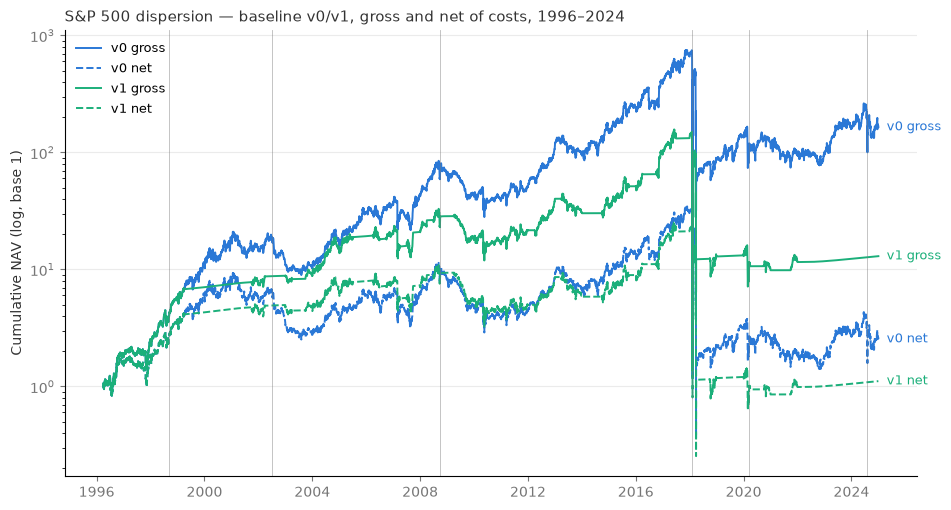

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

C_V0, C_V1, INK, MUTED = "#2a78d6", "#1baf7a", "#333333", "#767676"
fig, ax = plt.subplots(figsize=(11, 5.8))

for label, tag, color, ls in [("v0 gross", "v0", C_V0, "-"), ("v0 net", "v0_net", C_V0, "--"),
                              ("v1 gross", "v1", C_V1, "-"), ("v1 net", "v1_net", C_V1, "--")]:
    d = pd.read_parquet(P / f"backtest_{tag}_daily.parquet")
    nav = (1 + d["ret"].astype(float)).cumprod()
    ax.plot(pd.to_datetime(d["date"]), nav, color=color, ls=ls, lw=1.4, label=label)
    ax.annotate(label, xy=(pd.to_datetime(d["date"]).iloc[-1], nav.iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=9, color=color)

for dt, txt in [("1998-09-01", "LTCM"), ("2002-07-01", "2002"), ("2008-10-01", "GFC"),
                ("2018-02-05", "Volmageddon"), ("2020-03-16", "COVID"), ("2024-08-05", "2024")]:
    ax.axvline(pd.Timestamp(dt), color=MUTED, lw=0.6, alpha=0.5)
    ax.annotate(txt, xy=(pd.Timestamp(dt), ax.get_ylim()[0]), xytext=(2, 4),
                textcoords="offset points", fontsize=7.5, color=MUTED, rotation=90, va="bottom")

ax.set_yscale("log")
ax.set_ylabel("Cumulative NAV (log, base 1)", color=INK)
ax.set_title("S&P 500 dispersion — baseline v0/v1, gross and net of costs, 1996–2024",
             loc="left", fontsize=11, color=INK)
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.tick_params(colors=MUTED)
ax.xaxis.set_major_locator(mdates.YearLocator(4))

fig.savefig(ROOT / "results" / "figures" / "fig_backtest_s3.png", dpi=150, bbox_inches="tight")
plt.show()

## Week 3 conclusions

1. **The premium exists and the engine is validated**: v0 gross Sharpe ~0.77, Σy ≈ +100 % — the
   DMV Table II guardrails are reproduced without directed calibration.
2. **Frictions almost kill it** (replication of their Table V): net Sharpe 0.42 (theirs 0.41),
   ~3 %/yr net over 29 years — the limits-to-arbitrage narrative is complete and quantified.
3. **Naive timing is not enough**: v1 improves the premium per traded quarter and dodges
   2024/2002/Lehman, but trades the Volmageddon (the spread measures the richness of the premium,
   not the danger) and dies net of costs.
4. **S4 has its target**: predict spike regimes (RMT/ML), objective skew/tails — with a
   quantified bar: beat v0 net Sharpe 0.42 by cutting the −40/−90 % quarters.